In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn.datasets import fetch_california_housing


### Creating bunch named as 'housing_bunch' 
A Bunch object is a nifty container provided by Scikit-learn. Think of it as a well-organized box that holds not only your data but also valuable metadata (data about the data). A typical Bunch object for a dataset will contain: 'data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'

In [2]:
housing_bunch = fetch_california_housing()
# listing the keys and show us all the different pieces of information it contains.
print(housing_bunch.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])


In [3]:
print(housing_bunch.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

### Conversion of bunch object into pandas dataframe

In [4]:
housing_df = pd.DataFrame(data=housing_bunch.data, columns=housing_bunch.feature_names)

# The name 'MedHouseVal' is derived from the dataset's description, representing Median House Value.
housing_df['MedHouseVal'] = housing_bunch.target

housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [5]:
housing_df.shape

(20640, 9)

In [6]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [7]:
housing_df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


#### Key Observations and Insights:

1. Income Skewness (MedInc):
The mean (3.87) is higher than the median (3.53), which shows a right-skewed distribution. This means most households earn around the median income, but a few very high-income households increase the average. The max value of 15 supports this.

2. Outliers (AveRooms, AveBedrms, Population, AveOccup):
The maximum values in these columns are much higher than the mean and median. For example, 141 average rooms or a population above 35,000 in one census block seems unusual. These are likely outliers and may affect model performance.

3. Data Capping (HouseAge, MedHouseVal):

- HouseAge: The maximum value is exactly 52, which suggests all houses older than 52 were recorded as 52.
- MedHouseVal: The maximum value is 5.00001, meaning ```$500,001``` (since values are in  ```$100,000``` units). This clearly shows price capping, where values above $500,000 were limited.

Important Note:
Because of this capping, the model may not predict prices of expensive houses accurately.

### Understanding the Distribution with a Histogram via:
- Central Tendency: Where does the data cluster? (The tallest bars)
- Spread (Dispersion): How spread out is the data? (The width of the histogram)
- Skewness: Is the data symmetric, or does it have a long tail on one side?
- Outliers: Are there isolated bars far from the main group?

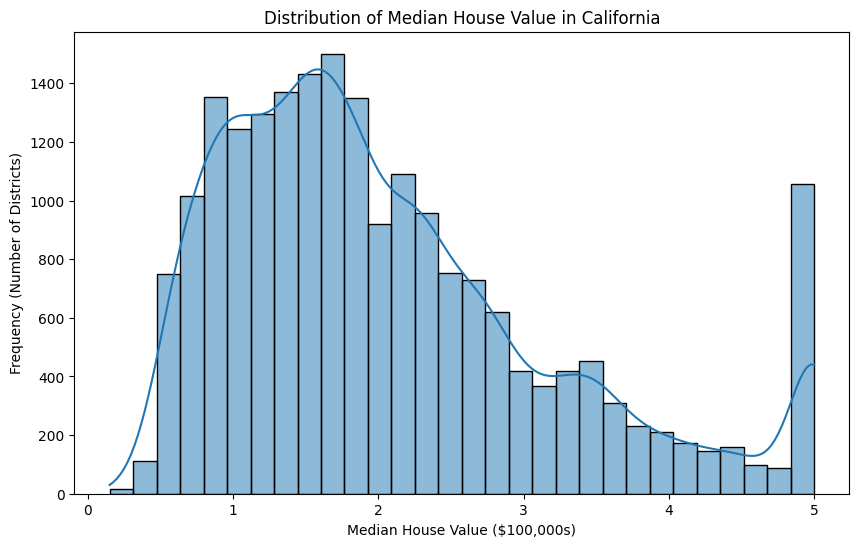

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(data=housing_df, x='MedHouseVal', bins=30, kde=True)

plt.title('Distribution of Median House Value in California')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency (Number of Districts)')
plt.show()

### Insights:
1. This is a classic right-skewed distribution. It visually shows us that most of the housing districts have a median value on the lower end (roughly between ```$100k``` and ```$250k```), with fewer and fewer districts as the price gets higher.
2. Very tall bar right at the 5.0 mark. This bar is much higher than its neighbors, indicating an unnatural pile-up of data points. This is the data capping we suspected! All districts with a median house value of $500,000 or more were simply recorded as being 5.0. This is a critical insight, as it tells us our model's predictions will be unreliable for very high-end properties.

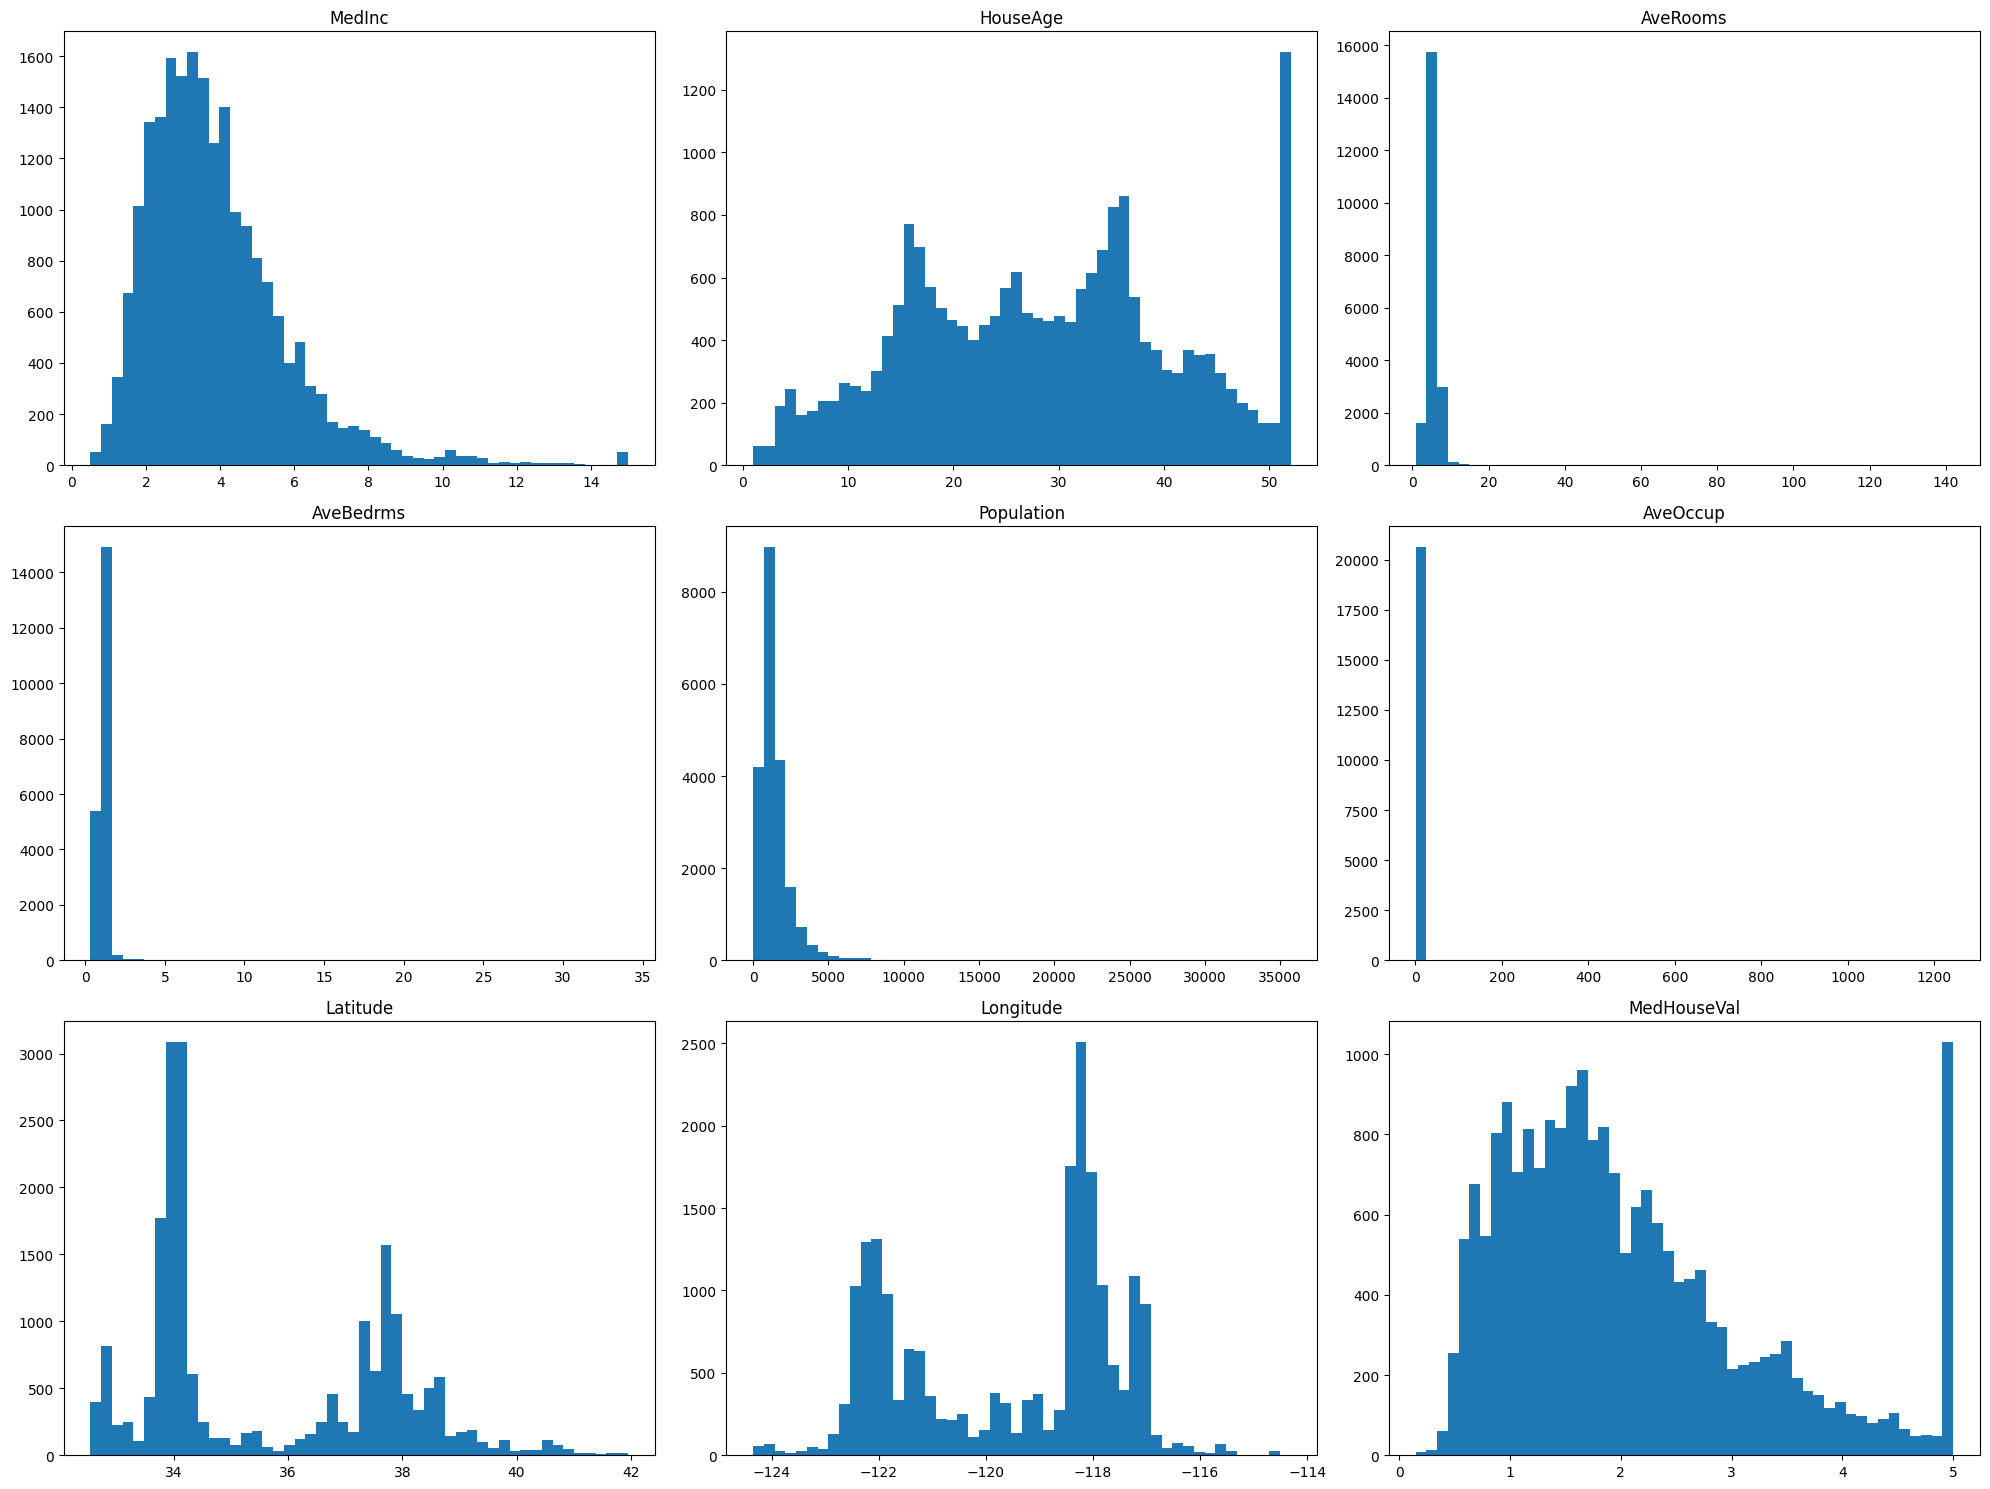

In [9]:
housing_df.hist(bins=50, figsize=(20, 15), grid=False)
plt.tight_layout()

plt.show()

### Key Insights from Histograms:

1. MedInc (Median Income):
This feature is right-skewed, meaning most households are in lower-to-middle income ranges, while fewer households have very high incomes.

2. HouseAge:
Mostly normal distribution, but a large spike at 52 years confirms data capping—houses older than 52 were likely recorded as 52.

3. AveRooms, AveBedrms, Population, AveOccup:
These features are highly right-skewed with long tails, showing the presence of outliers. Most values are low, but a few extreme values are very high.

4. Latitude and Longitude:
These features show multiple peaks instead of skewness, indicating dense population clusters in different regions of California, such as around Los Angeles and San Francisco.

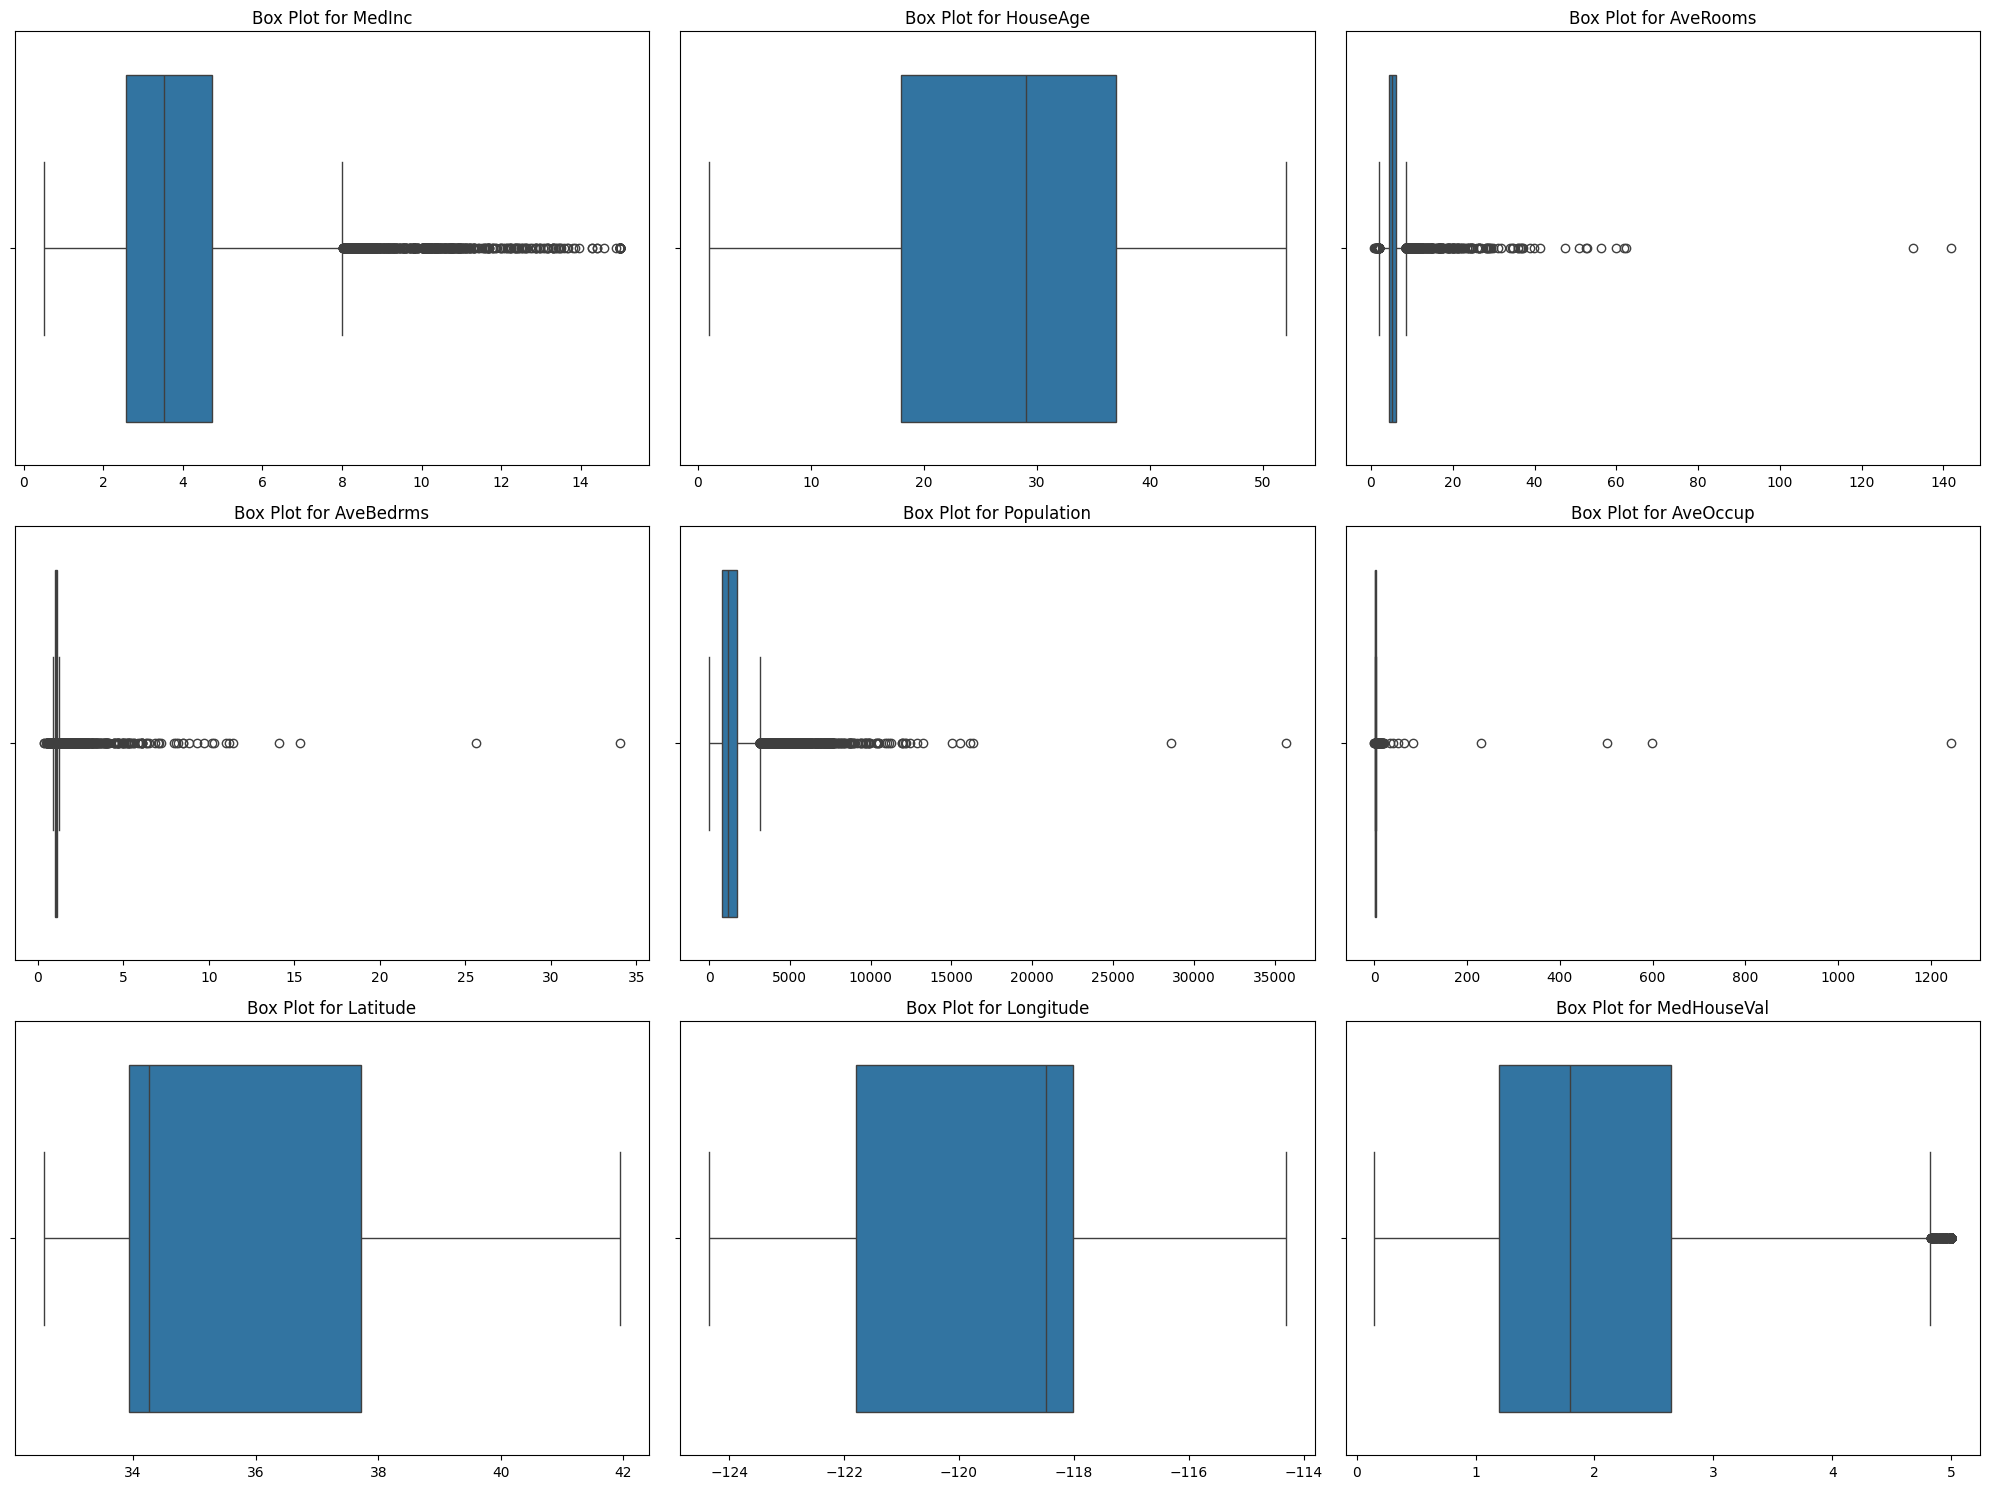

In [10]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))

# The `axes` object is a 2D NumPy array of plot objects. We can flatten it
# into a 1D array to make it easier to loop over.
axes = axes.flatten()

# Loop through each column in the DataFrame and its corresponding subplot axis.
# `zip` is a handy function that pairs up elements from two lists.
for col, ax in zip(housing_df.columns, axes):
    sns.boxplot(x=housing_df[col], ax=ax)
    ax.set_title(f'Box Plot for {col}', fontsize=12)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

### Insights:
- The Heavily Skewed Features (AveRooms, AveBedrms, Population, AveOccup): These are the most dramatic plots. 
- Capped Features (HouseAge, MedHouseVal): These plots look more "normal" but you'll see the top whisker extends right up to the maximum value (52 for HouseAge, 5 for MedHouseVal). This is another visual sign of the data capping, as there are no "outliers" above this hard limit.
- Geographical Features (Latitude, Longitude): These features have relatively "healthy" looking box plots with few outliers, indicating that the geographical coordinates are mostly contained within a well-defined range.
- Median Income (MedInc): This plot will show a distribution with several outliers on the high end, visually confirming the right-skew we saw in the histogram.

### Bivariate Analysis: Visualizing Feature Relationships with Scatter Plots

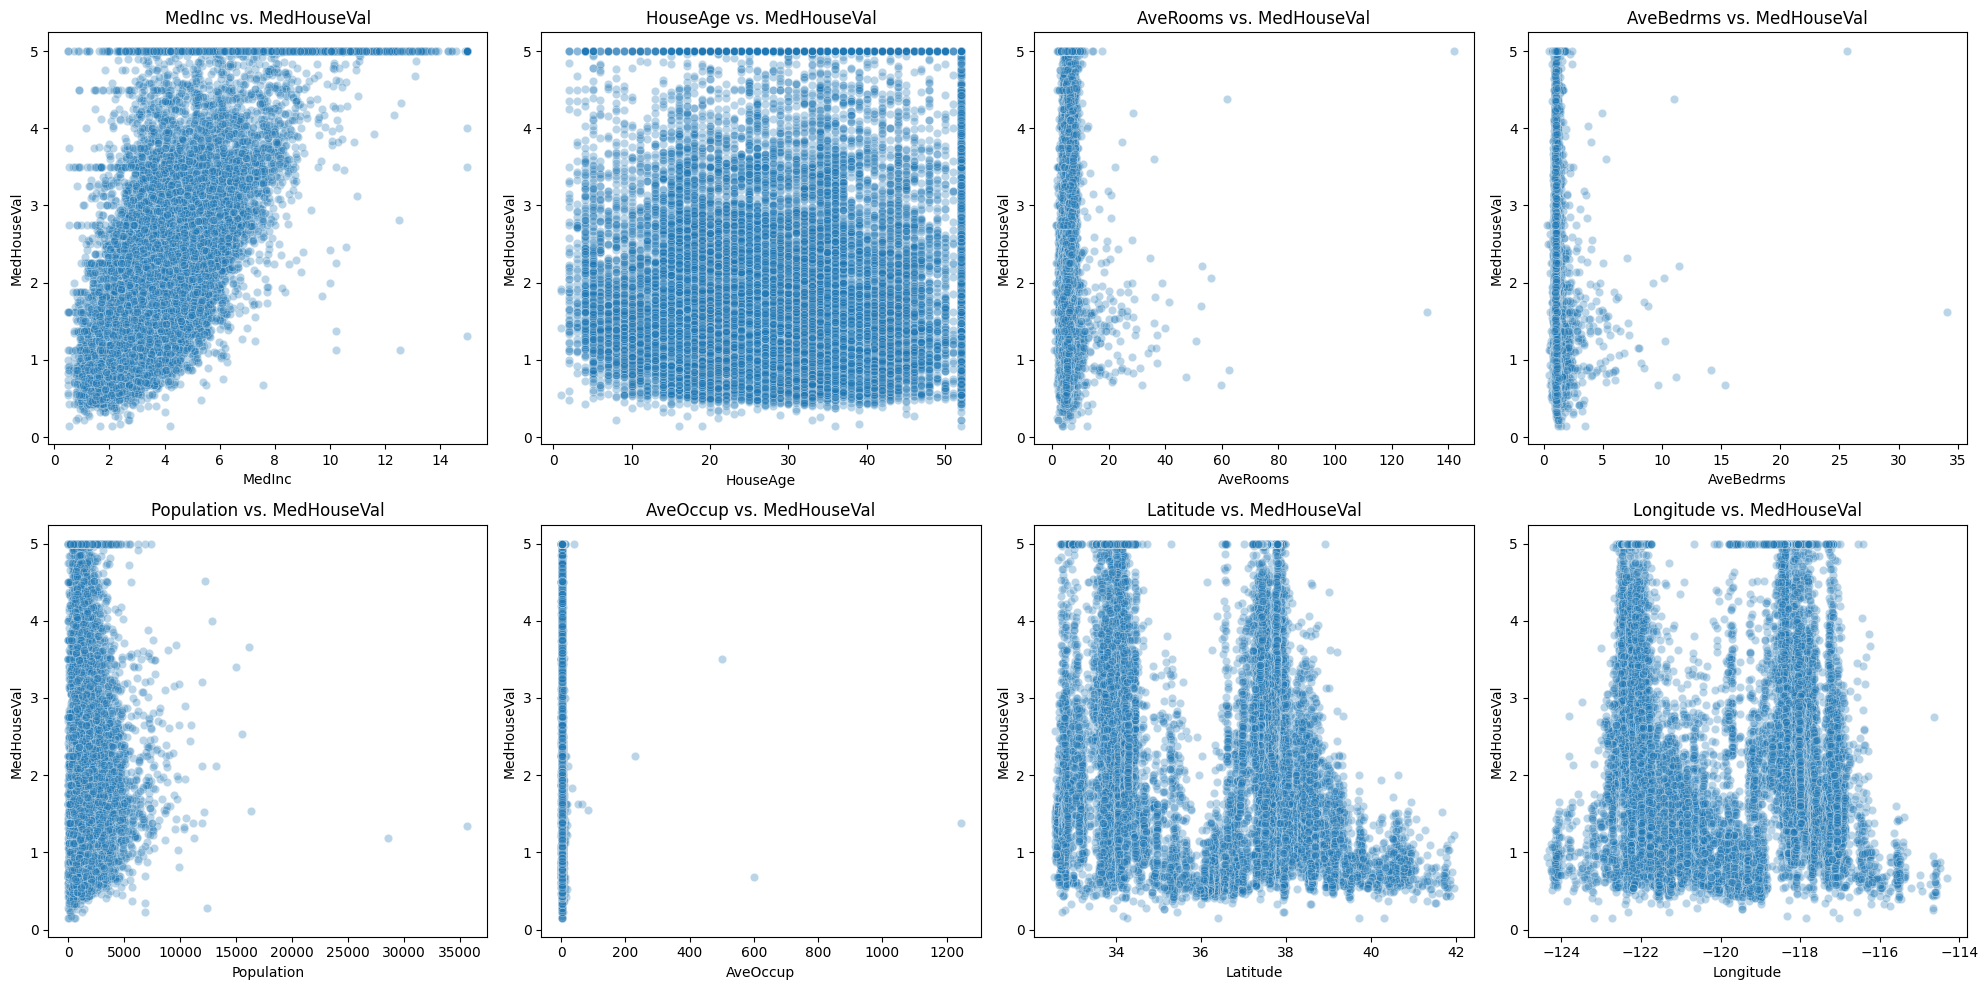

In [11]:
features = housing_df.columns.drop('MedHouseVal')
target = 'MedHouseVal'

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    # alpha: Sets the transparency of the points. 0.3 means 30% opacity.
    #        This is crucial for dense datasets to reveal areas of high point concentration.
    sns.scatterplot(x=feature, y=target, data=housing_df, ax=axes[i], alpha=0.3)
    axes[i].set_title(f'{feature} vs. {target}')
    
plt.tight_layout()
plt.show()

### Insight:
- MedInc vs MedHouseVal: Strongest positive relationship; higher area income usually means higher house prices.
- AveRooms vs MedHouseVal: Slight positive trend; more rooms may increase price, but relationship is noisy with outliers.
- HouseAge vs MedHouseVal: Weak relationship; age alone does not predict house price well.
- Price Cap at 5: House values are capped at 5, visible as a horizontal line across plots.
- Population & AveOccup: Very scattered patterns, showing weak influence on house prices.

**Key Insight:** MedInc is the most important feature for predicting house value.

### Visualizing Geographical Data
Scatter plot of 'Longitude' vs 'Latitude' to create a map-like visualization. This will help us see if there are geographical patterns in the data and how house prices are distributed across the state of California.

Effective in answering questions like:

- Does our data actually look like the state of California? (A great sanity check!)
- Where are the houses in our dataset concentrated? Are they clustered in cities or spread out evenly?
- Are there any sparsely populated areas?

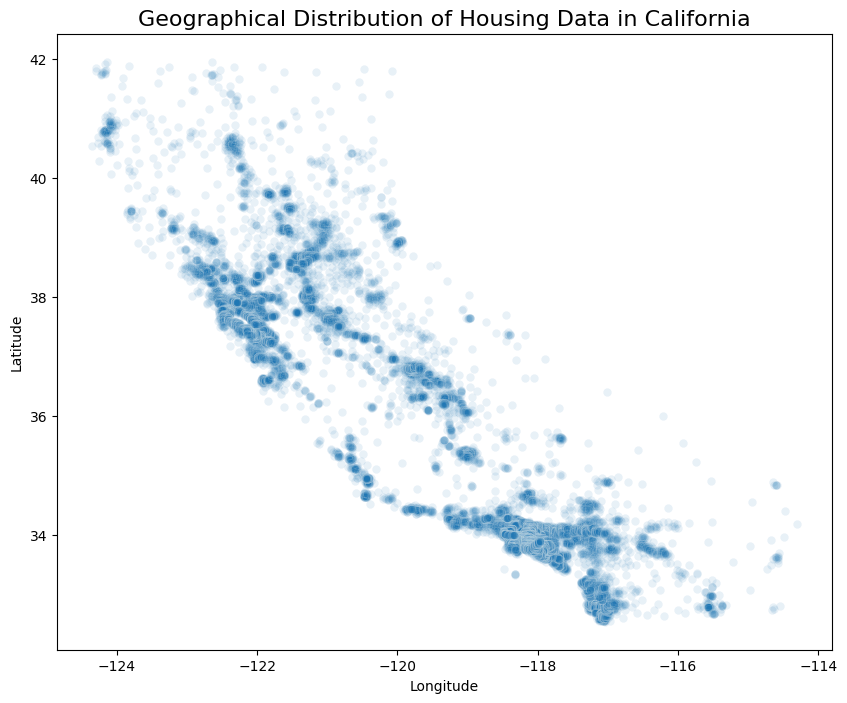

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=housing_df, 
    x='Longitude', 
    y='Latitude',
    # Here is the crucial parameter for handling overplotting.
    # A low alpha value makes points transparent, so areas with many points become darker.
    # This effectively creates a heat map of data point density.
    alpha=0.1 
)

plt.title('Geographical Distribution of Housing Data in California', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

This plot that looks remarkably like a map of California.

- Coastal Concentration: Dense clusters along the coast represent highly populated regions such as the San Francisco Bay Area and Los Angeles–San Diego corridor.
- Inland Sparsity: Central Valley and eastern regions show lighter density, indicating fewer housing districts and lower population concentration.

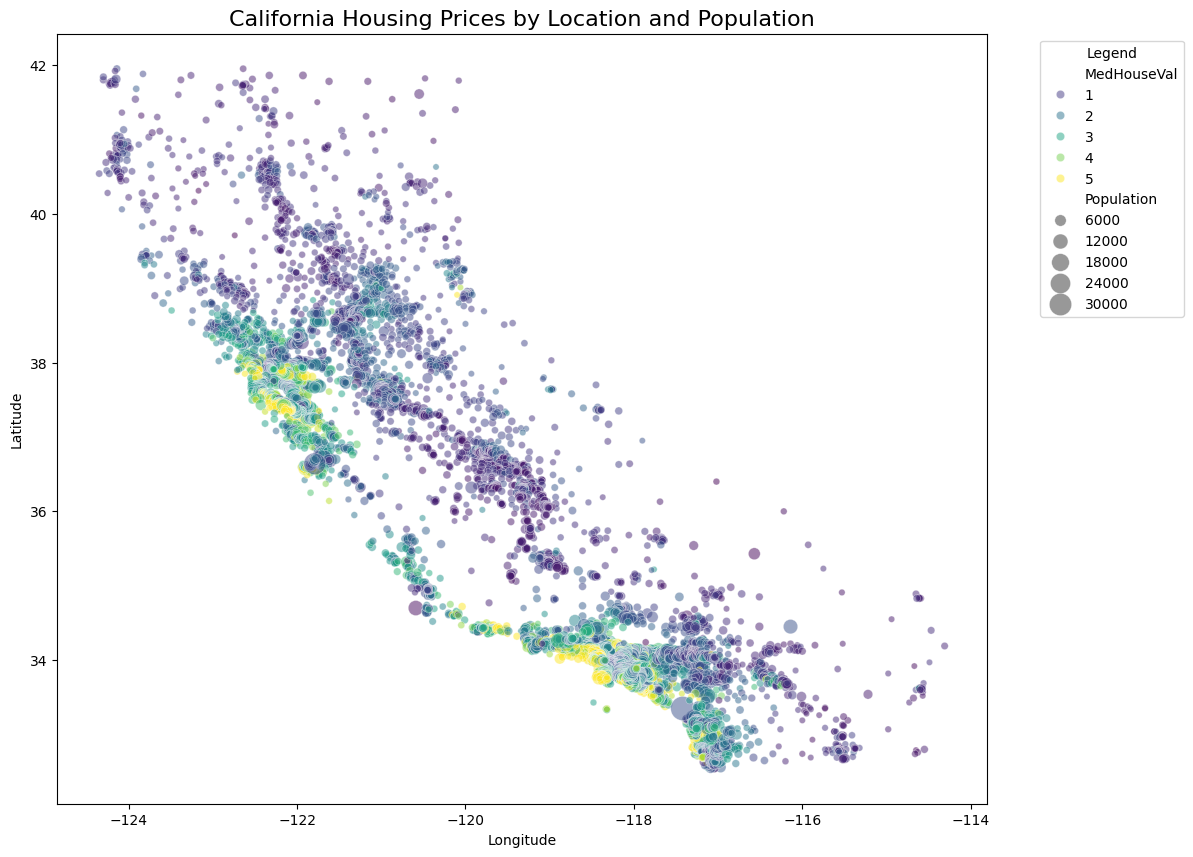

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.scatterplot(
    data=housing_df, 
    x='Longitude', 
    y='Latitude',

    # `hue` will color the points based on the 'MedHouseVal' column.
    hue='MedHouseVal',
    
    # `size` will adjust the size of the points based on the 'Population' column.
    size='Population',
    palette='viridis',
    sizes=(20, 300),
    alpha=0.5
)

plt.title('California Housing Prices by Location and Population', fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')

# The legend might get crowded, so let's position it nicely.
# 'bbox_to_anchor' places the legend outside the plot area.
plt.legend(title='Legend', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Insights:
- Coastal Price Hotspots: Highest house prices are concentrated along the coast, especially in the San Francisco Bay Area and Southern California.
- Population vs Price: Some areas have both high population and high prices (large bright dots), while some smaller coastal towns have high prices despite lower population.
- Affordable High-Population Areas: Some inland cities have large populations but moderate house prices.
- Inland Empire: East of Los Angeles has dense population with relatively more affordable housing.

In [14]:
corr_matrix = housing_df.corr()
print("Correlation with Target Variable (MedHouseVal):")
corr_matrix['MedHouseVal'].sort_values(ascending=False)

Correlation with Target Variable (MedHouseVal):


MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

### Insight:
1. MedInc (0.69): This is a strong positive correlation. This number, 0.69, quantifies the clear upward trend we saw in the scatter plot. It is, by far, the most powerful linear predictor of house price in our dataset.
2. Negative Correlations (Latitude at -0.14): This is an interesting finding. The negative correlation with Latitude suggests that, on average, as you move north (latitude increases), the median house price tends to decrease. While seemingly at odds with the high prices in the Bay Area, this reflects the overall trend across the entire state, which includes many less expensive northern counties.

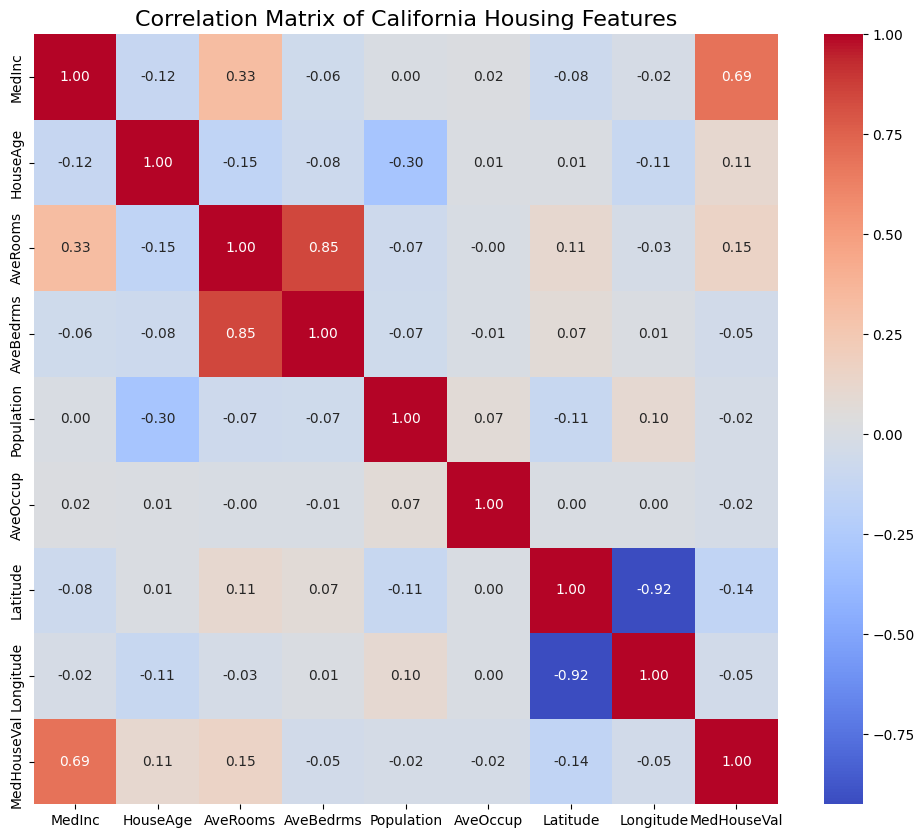

In [15]:
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of California Housing Features', fontsize=16)
plt.show()

### Insight:
1. Strongest Positive Correlation: Median Income has the highest positive correlation with MedHouseVal (0.69), making it the strongest predictor.
2. Negative Correlation: Latitude (-0.14) shows a slight negative correlation, meaning house prices tend to decrease as you move north.
3. Multicollinearity: AveRooms and AveBedrms (0.85) have a strong positive correlation, indicating possible multicollinearity.

## Data Preprocessing:

In [16]:
housing_df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Feature Engineering

We calculate ```rooms_per_person``` using ```AveRooms``` (average rooms per household) and ```AveOccup``` (average household occupancy).
- AveRooms = Total Rooms / Number of Households
- AveOccup = Population / Number of Households
  
Thus, from these two columns ```rooms_per_person = Total Rooms / Population```

In [17]:
housing_df['rooms_per_person'] = housing_df['AveRooms'] / housing_df['AveOccup']
print("DataFrame with the new 'rooms_per_person' feature:")
housing_df.head()

DataFrame with the new 'rooms_per_person' feature:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal,rooms_per_person
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,2.732919
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,2.956685
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,2.957661
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,2.283154
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,2.879646


In [18]:
print("\nStatistical summary of the new feature:")
housing_df[['rooms_per_person']].describe()


Statistical summary of the new feature:


,rooms_per_person
count,20640.000000
mean,1.976970
std,1.146020
min,0.002547
25%,1.522382
50%,1.937936
75%,2.296090
max,55.222222


We calcuate using ```bedrooms_per_room``` using AveRooms and AveBedrms.
- AveBedrms = Total Bedrooms / Number of Households
- AveRooms = Total Rooms / Number of Households

Thus, from these two columns: ```bedrooms_per_room = total bedrooms / total rooms```

Like, a 6-room house with 1 kitchen, 1 living room, 1 dining room, and 3 bedrooms would have a ratio of 3/6 = 0.5

In [19]:
housing_df['bedrooms_per_room'] = housing_df['AveBedrms'] / housing_df['AveRooms']
print("\nStatistical summary of the new 'bedrooms_per_room' feature:")
display(housing_df[['bedrooms_per_room']].describe())


Statistical summary of the new 'bedrooms_per_room' feature:


,bedrooms_per_room
count,20640.000000
mean,0.213075
std,0.058023
min,0.100000
25%,0.175426
50%,0.203181
75%,0.239834
max,1.000000


Since, max value is 1.0 which shows the presence of some very unusual properties (outliers) in the dataset.

### Data Splitting:

In [20]:
X = housing_df.drop('MedHouseVal', axis=1)
y = housing_df['MedHouseVal']

print("Shape of X: ", X.shape)
print("Shape of y: ", y.shape)

Shape of X:  (20640, 10)
Shape of y:  (20640,)


In [21]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("--- Shapes of the Datasets ---")
print("Original X shape:", X.shape)
print("X_train shape:   ", X_train.shape)
print("X_test shape:    ", X_test.shape)
print("\nOriginal y shape:", y.shape)
print("y_train shape:   ", y_train.shape)
print("y_test shape:    ", y_test.shape)

--- Shapes of the Datasets ---
Original X shape: (20640, 10)
X_train shape:    (16512, 10)
X_test shape:     (4128, 10)

Original y shape: (20640,)
y_train shape:    (16512,)
y_test shape:     (4128,)


### Scaling:
We use standardization where we calculate 'z', often called a z-score. It represents how many standard deviations a given data point is away from the mean.

By applying this transformation, we ensure that every feature in our dataset has the same central point (a mean of 0) and the same spread (a standard deviation of 1), all without changing the fundamental shape of its distribution.

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

print("\nLearned Means (one for each of our 10 features):")
print(scaler.mean_)

print("\nLearned Standard Deviations (one for each of our 10 features):")
print(scaler.scale_)


Learned Means (one for each of our 10 features):
[ 3.88075426e+00  2.86082849e+01  5.43523502e+00  1.09668475e+00
  1.42645300e+03  3.09696119e+00  3.56431492e+01 -1.19582290e+02
  1.98058241e+00  2.12857974e-01]

Learned Standard Deviations (one for each of our 10 features):
[1.90423626e+00 1.26021177e+01 2.38730258e+00 4.33201426e-01
 1.13702195e+03 1.15783935e+01 2.13660060e+00 2.00559281e+00
 1.12578341e+00 5.79936352e-02]


In [23]:
# Transform the training data
X_train_scaled_np = scaler.transform(X_train)

# Transform the testing data
X_test_scaled_np = scaler.transform(X_test)

# 3. Convert the scaled NumPy arrays back to pandas DataFrames
X_train_scaled = pd.DataFrame(X_train_scaled_np, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_np, columns=X.columns, index=X_test.index)

print("--- Scaled Training Data (X_train_scaled) ---")
display(X_train_scaled.head())

print("\n--- Statistical Summary of Scaled Training Data ---")
display(X_train_scaled.describe())

--- Scaled Training Data (X_train_scaled) ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedrooms_per_room
14196,-0.326196,0.348490,-0.174916,-0.208365,0.768276,0.051376,-1.372811,1.272587,-0.552017,-0.211785
8267,-0.035843,1.618118,-0.402835,-0.128530,-0.098901,-0.117362,-0.876696,0.709162,0.526956,0.342185
17445,0.144701,-1.952710,0.088216,-0.257538,-0.449818,-0.032280,-0.460146,-0.447603,0.082291,-0.661658
14265,-1.017864,0.586545,-0.600015,-0.145156,-0.007434,0.077507,-1.382172,1.232698,-0.869143,0.783032
2271,-0.171488,1.142008,0.349007,0.086624,-0.485877,-0.068832,0.532084,-0.108551,0.661600,-0.550364



--- Statistical Summary of Scaled Training Data ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedrooms_per_room
count,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04,1.651200e+04
mean,-6.519333e-17,-9.251859e-18,-1.981081e-16,-1.707291e-16,-2.151595e-19,4.936566e-17,6.400995e-17,1.753335e-15,1.527632e-17,-5.927644e-17
std,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00
min,-1.775438e+00,-2.190766e+00,-1.904386e+00,-1.762117e+00,-1.251913e+00,-2.076846e-01,-1.447697e+00,-2.377207e+00,-1.757030e+00,-1.946041e+00
25%,-6.900689e-01,-8.417859e-01,-4.118373e-01,-2.081645e-01,-5.606339e-01,-5.770769e-02,-8.018107e-01,-1.110749e+00,-4.035763e-01,-6.497310e-01
50%,-1.758995e-01,3.108328e-02,-8.350905e-02,-1.094160e-01,-2.281865e-01,-2.415892e-02,-6.473597e-01,5.346501e-01,-3.467976e-02,-1.733004e-01
75%,4.686502e-01,6.658972e-01,2.621376e-01,8.455177e-03,2.634487e-01,1.580865e-02,9.720351e-01,7.839530e-01,2.842758e-01,4.594195e-01
max,5.839268e+00,1.856173e+00,5.716655e+01,5.664727e+01,3.012743e+01,1.071164e+02,2.951816e+00,2.628794e+00,4.446037e+01,1.357290e+01


The mean of each column should be very close to 0, and the std dev should be very close to 1.

## Model Training:
A baseline model is used first as it is a simple, often traditional, model that is easy to train and interpret. Its purpose is twofold:

- Sanity Check: It provides a quick way to see if there is any predictive signal in the data at all. If a simple model can't predict better than random guessing, you might need to revisit your features or data collection.
  
- Benchmark for Comparison: The performance of the baseline model sets the bar. Any more complex model we build later (like a Random Forest) must perform significantly better than this baseline to justify its increased complexity. If a fancy model doesn't beat the simple one, the simple one is often the better choice.

In [24]:
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_scaled, y_train)
print(lr.coef_)
print("\n")
print(lr.intercept_)

[ 0.79012123  0.12842294 -0.14690057 -0.22545214  0.03227174 -0.01783871
 -0.88631613 -0.83447052  0.51954145  0.2414413 ]


2.0719469373788773


In [25]:
# This makes it much easier to see which features the model found to be most influential.
feature_weights = pd.Series(lr.coef_, index=X.columns)
print("\n--- Interpreted Feature Weights ---")
print(feature_weights.sort_values(ascending=False))


--- Interpreted Feature Weights ---
MedInc               0.790121
rooms_per_person     0.519541
bedrooms_per_room    0.241441
HouseAge             0.128423
Population           0.032272
AveOccup            -0.017839
AveRooms            -0.146901
AveBedrms           -0.225452
Longitude           -0.834471
Latitude            -0.886316
dtype: float64


In [26]:
lr_predictions = lr.predict(X_test_scaled)
pd.DataFrame(lr_predictions)

,0
0,0.538489
1,1.716224
2,3.271458
3,2.647866
4,2.656293
...,...
4123,2.040538
4124,2.366961
4125,4.503408
4126,1.278905


In [27]:
display(pd.Series(lr_predictions).describe())

count    4128.000000
mean        2.048025
std         0.931145
min        -0.869577
25%         1.459152
50%         1.996856
75%         2.570539
max         7.709800
dtype: float64

In [28]:
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train_scaled, y_train)
tree_predictions = tree.predict(X_test_scaled)
print(tree_predictions)

[0.476   0.521   5.      ... 5.00001 0.638   1.691  ]


You've now seen the power and the primary weakness of a single Decision Tree. It can capture complex patterns, but it's highly prone to overfitting. So, how can we keep the model's ability to learn complex rules while making it more robust and less likely to memorize noise?

The answer lies in a concept called ensemble learning. Instead of relying on the judgment of a single, complex tree, what if we built hundreds of simpler trees and let them vote on the final prediction?

In [29]:
from sklearn.ensemble import RandomForestRegressor
forest = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
forest.fit(X_train_scaled, y_train)
fr_predictions = forest.predict(X_test_scaled)
fr_predictions

array([0.49279  , 0.81716  , 4.9636277, ..., 4.8514087, 0.71405  ,
       1.67236  ])

### Evaluation metrics:

In [30]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr_mse = mean_squared_error(y_test, lr_predictions)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_predictions)

print("--- Linear Regressor Evaluation ---")
print(f"Mean Squared Error (MSE): {lr_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {lr_rmse:.4f}")
print(f"R-squared (R²): {lr_r2:.4f}")

--- Linear Regressor Evaluation ---
Mean Squared Error (MSE): 0.4561
Root Mean Squared Error (RMSE): 0.6753
R-squared (R²): 0.6519


In [31]:
tree_mse = mean_squared_error(y_test, tree_predictions)
tree_rmse = np.sqrt(tree_mse)
tree_r2 = r2_score(y_test, tree_predictions)

print("--- Decision Tree Regressor Evaluation ---")
print(f"Mean Squared Error (MSE): {tree_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {tree_rmse:.4f}")
print(f"R-squared (R²): {tree_r2:.4f}")

--- Decision Tree Regressor Evaluation ---
Mean Squared Error (MSE): 0.5145
Root Mean Squared Error (RMSE): 0.7173
R-squared (R²): 0.6074


In [32]:
forest_mse = mean_squared_error(y_test, fr_predictions)
forest_rmse = np.sqrt(forest_mse)
forest_r2 = r2_score(y_test, fr_predictions)

print("--- Random Forest Regressor Evaluation ---")
print(f"Mean Squared Error (MSE): {forest_mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {forest_rmse:.4f}")
print(f"R-squared (R²): {forest_r2:.4f}")

--- Random Forest Regressor Evaluation ---
Mean Squared Error (MSE): 0.2549
Root Mean Squared Error (RMSE): 0.5048
R-squared (R²): 0.8055


- **Root Mean Squared Error (RMSE):** Our baseline Linear Regression had a typical error of ```~$67,530```. The overfit Decision Tree was even worse. Your Random Forest model has slashed this error to approximately $50,480! This is a massive improvement in accuracy.
  
- **R-squared (R²):** Our baseline model could explain about 65% of the variance in house prices. The Random Forest model explains a remarkable 80.55% of the variance. It is capturing a significantly larger portion of the underlying patterns that determine a house's price.

### Comparison DataFrame

In [33]:
model_performance_data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE': [lr_mse, tree_rmse, forest_rmse],
    'R-squared': [lr_r2, tree_r2, forest_r2]
}

results_df = pd.DataFrame(model_performance_data)

results_df['RMSE'] = results_df['RMSE'].round(4)
results_df['R-squared'] = results_df['R-squared'].round(4)

print("--- Model Performance Comparison ---")
display(results_df)

--- Model Performance Comparison ---


,Model,RMSE,R-squared
0,Linear Regression,0.4561,0.6519
1,Decision Tree,0.7173,0.6074
2,Random Forest,0.5048,0.8055


### Hyperparameter Tuning:

In [35]:
from sklearn.model_selection import RandomizedSearchCV
rf_for_tuning = RandomForestRegressor(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [20, None],
    'max_features': ['sqrt', 0.8],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=param_grid,
    n_iter=40,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_scaled, y_train)
best_parameters = random_search.best_params_

# Print the results in a user-friendly format.
print("The best combination of hyperparameters found by GridSearchCV is:")
print(best_parameters)

C:\Users\Kashish Pundir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 32 candidates, totalling 96 fits
The best combination of hyperparameters found by GridSearchCV is:
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 0.8, 'max_depth': 20}


In [37]:
best_score = random_search.best_score_
print(f"\nBest cross-validation score (Negative MSE): {best_score:.4f}")
# We take the absolute value (to remove the negative) and then the square root.
best_rmse = np.sqrt(-best_score)
print(f"Equivalent RMSE from cross-validation: {best_rmse:.4f}")


Best cross-validation score (Negative MSE): -0.2631
Equivalent RMSE from cross-validation: 0.5129


In [39]:
final_model = random_search.best_estimator_
final_model

,n_estimators,300
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,0.8
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Now, we evaluate this new tuned final_model on the test set (X_test_scaled, y_test) and compare its performance (RMSE and R²) to the default Random Forest model.

In [40]:
tuned_predictions = final_model.predict(X_test_scaled)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
tuned_r2 = r2_score(y_test, tuned_predictions)

print("--- Tuned Random Forest Regressor Evaluation ---")
print(f"Root Mean Squared Error (RMSE): {tuned_rmse:.4f}")
print(f"R-squared (R²): {tuned_r2:.4f}\n")

comparison_data = {
    'Model': ['Default Random Forest', 'Tuned Random Forest'],
    'RMSE': [forest_rmse, tuned_rmse],
    'R-squared': [forest_r2, tuned_r2]
}

final_comparison_df = pd.DataFrame(comparison_data)

final_comparison_df['RMSE'] = final_comparison_df['RMSE'].round(4)
final_comparison_df['R-squared'] = final_comparison_df['R-squared'].round(4)

print("--- Final Performance Comparison ---")
display(final_comparison_df)

--- Tuned Random Forest Regressor Evaluation ---
Root Mean Squared Error (RMSE): 0.5007
R-squared (R²): 0.8087

--- Final Performance Comparison ---


,Model,RMSE,R-squared
0,Default Random Forest,0.5048,0.8055
1,Tuned Random Forest,0.5007,0.8087


- RMSE Improvement: The typical prediction error has decreased from ~$50.480 to ~$50.33. In a real estate context, reducing the average error by over $1,200 per prediction is a tangible and valuable improvement.
- R-squared Improvement: The tuned model now explains 82.2% of the variance in house prices, up from 81.3%. This means our model is now capturing more of the underlying patterns that determine price, making it a more accurate and reliable tool.

### Model Interpretability:

In [41]:
feature_importances = final_model.feature_importances_
feature_importances_series = pd.Series(feature_importances, index=X.columns).sort_values(ascending=False)

print("Feature Importances with their corresponding names:")
display(feature_importances_series)



Feature Importances with their corresponding names:


MedInc               0.489615
AveOccup             0.114742
Latitude             0.087644
Longitude            0.086248
bedrooms_per_room    0.051950
HouseAge             0.051234
rooms_per_person     0.049653
AveRooms             0.024943
Population           0.023878
AveBedrms            0.020092
dtype: float64

### Model Persistence via Joblib (saving a trained model object (and any other necessary objects, like our data scaler)):

Standard way to save arbitrary Python objects is through a process called serialization.

In [42]:
import joblib
model_filename = 'final_model.joblib'
joblib.dump(final_model, model_filename)

scaler_filename = 'scaler.joblib'
joblib.dump(scaler, scaler_filename)

['scaler.joblib']

### Verification of saved ML model and scaler:

In [43]:
# Load the Saved Assets 
loaded_model = joblib.load('final_model.joblib')
loaded_scaler = joblib.load('scaler.joblib')

print("--- Assets Loaded Successfully ---")
print("Loaded Model:", loaded_model)
print("Loaded Scaler:", loaded_scaler)

# Prepare a Sample Raw Data Point
# We will take the first row of our unscaled test set (X_test) as a sample.
sample_raw_data = X_test.iloc[[0]]

print("\n--- Raw Sample Data (Simulating User Input) ---")
display(sample_raw_data)

# Transform the Sample Data with the Loaded Scaler 
sample_scaled_data = loaded_scaler.transform(sample_raw_data)

print("\n--- Scaled Sample Data (Ready for the Model) ---")
print(sample_scaled_data)

# Make a Prediction with the Loaded Model
prediction = loaded_model.predict(sample_scaled_data)

# Display the Result and Verify 
predicted_price = prediction[0]

# Get the actual price for this same house from the y_test Series.
actual_price = y_test.iloc[0]

print("\n--- Verification Complete ---")
print(f"Prediction for the sample house: ${predicted_price:,.2f} (in hundreds of thousands)")
print(f"Actual price for the sample house: ${actual_price:,.2f} (in hundreds of thousands)")
print("\nSuccess! The loaded model and scaler are working correctly.")

--- Assets Loaded Successfully ---
Loaded Model: RandomForestRegressor(max_depth=20, max_features=0.8, min_samples_leaf=2,
                      n_estimators=300, n_jobs=-1, random_state=42)
Loaded Scaler: StandardScaler()

--- Raw Sample Data (Simulating User Input) ---


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,rooms_per_person,bedrooms_per_room
20046,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01,1.081178,0.243854



--- Scaled Sample Data (Ready for the Model) ---
[[-1.15508475 -0.28632369 -0.52068576 -0.17174603 -0.03030109  0.06740798
   0.1951      0.28534728 -0.79891411  0.53446979]]

--- Verification Complete ---
Prediction for the sample house: $0.49 (in hundreds of thousands)
Actual price for the sample house: $0.48 (in hundreds of thousands)

Success! The loaded model and scaler are working correctly.


C:\Users\Kashish Pundir\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
